# Text Classification

This notebook uses a small BERT model to classify short headlines as sarcastic or not sarcastic.


In [1]:
# The small sample text dataset used here is included in this repository.

In [2]:
import torch
import torch.nn as nn
from torch.optim import Adam
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

C:\Users\iiiss\anaconda3\envs\lawly\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load headline data

The included JSON lines file keeps the example small and easy to rerun.


In [3]:
df = pd.read_json('news-headlines-dataset-for-sarcasm-detection/Sarcasm_Headlines_Dataset.json', lines=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
print(df.shape)
df.head()

(20, 3)


,article_link,headline,is_sarcastic
0,,Area man bravely opens another tab to solve al...,1
1,,Local student shocked that model trains better...,1
2,,Computer politely asks for one more dependency,1
3,,Experts confirm coffee is now a machine learni...,1
4,,Notebook claims it worked on my machine and re...,1


In [4]:
df.drop(columns='article_link', inplace = True)
df

,headline,is_sarcastic
0,Area man bravely opens another tab to solve al...,1
1,Local student shocked that model trains better...,1
2,Computer politely asks for one more dependency,1
3,Experts confirm coffee is now a machine learni...,1
4,Notebook claims it worked on my machine and re...,1
5,Dataset celebrates being split for the fifth t...,1
6,Tiny model announces plans to understand the e...,1
7,Chart improves project morale by going upward,1
8,Developer fixes bug by staring at it professio...,1
9,Training loop says it has learned valuable les...,1


In [5]:
X_train , X_temp , y_train , y_temp = train_test_split(np.array(df['headline']), np.array(df['is_sarcastic']), test_size=0.326, random_state=42)
X_val , X_test , y_val , y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

X_train shape: (13,)
X_test shape: (4,)
y_train shape: (13,)
y_test shape: (4,)
X_val shape: (3,)
y_val shape: (3,)


## Tokenize text

A lightweight BERT checkpoint is used for a practical demo.


In [6]:
tokenizer = AutoTokenizer.from_pretrained("prajjwal1/bert-tiny")
# bert = AutoModelForMaskedLM.from_pretrained("google-bert/bert-base-uncased")
bert = AutoModel.from_pretrained("prajjwal1/bert-tiny")

C:\Users\iiiss\anaconda3\envs\lawly\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [7]:
from torch.utils.data import Dataset, DataLoader
class Data(Dataset):
  def __init__(self, X, y):
    self.X = [tokenizer(x, max_length=100, truncation=True, padding="max_length", return_tensors='pt').to(device) for x in X]
    self.y = torch.tensor(y, dtype=torch.float).to(device)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

train_data = Data(X_train, y_train)
val_data = Data(X_val, y_val)
test_data = Data(X_test, y_test)

In [8]:
BATCH_SIZE = 32
EPOCHS = 2
LR = 1e-4

In [9]:
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

## Build the classifier

The BERT output is passed into a small neural network head.


In [10]:
class Zen(nn.Module):
  def __init__(self, bert):
    super(Zen, self).__init__()

    self.bert = bert
    self.drop = nn.Dropout(0.3)
    self.linear1 = nn.Linear(bert.config.hidden_size, 64)
    self.linear2 = nn.Linear(64, 1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, input_ids, attention_mask):
    pooled_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)[0][:,0]
    output = self.linear1(pooled_output)
    output = self.drop(output)
    output = self.linear2(output)
    output = self.sigmoid(output)

    return output

In [11]:
for params in bert.parameters():
  params.requires_grad = False
model = Zen(bert).to(device)

In [12]:
loss_fn = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=LR)

In [13]:
loss_train = []
loss_val = []
acc_train = []
acc_val = []

for epoch in range(EPOCHS):
  total_loss_train = 0
  total_acc_train = 0
  total_loss_val = 0
  total_acc_val = 0

  for idx, data in enumerate(train_loader):
    inputs, labels = data
    inputs.to(device)
    labels.to(device)

    preds = model(inputs['input_ids'].squeeze(1), inputs['attention_mask'].squeeze(1)).squeeze(1)
    loss = loss_fn(preds, labels)
    total_loss_train += loss.item()

    acc = (preds.round() == labels).sum().item()
    total_acc_train += acc

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  with torch.no_grad():
    for idx, data in enumerate(val_loader):
      inputs, labels = data
      inputs.to(device)
      labels.to(device)

      preds = model(inputs['input_ids'].squeeze(1), inputs['attention_mask'].squeeze(1)).squeeze(1)

      loss = loss_fn(preds, labels)
      total_loss_val += loss.item()

      acc = (preds.round() == labels).sum().item()
      total_acc_val += acc
  loss_train.append(round(total_loss_train/len(train_loader), 4))
  loss_val.append(round(total_loss_val/len(val_loader), 4))
  acc_train.append(round((total_acc_train/train_data.__len__()) * 100,4))
  acc_val.append(round((total_acc_val/val_data.__len__()) * 100, 4))

  print(f"Epoch: {epoch+1}/{EPOCHS}")
  print(f"Train Loss: {loss_train[-1]} | Train Acc: {acc_train[-1]}")
  print(f"Val Loss: {loss_val[-1]} | Val Acc: {acc_val[-1]}")

Epoch: 1/2
Train Loss: 0.7587 | Train Acc: 46.1538
Val Loss: 0.5243 | Val Acc: 100.0
Epoch: 2/2
Train Loss: 0.7657 | Train Acc: 30.7692
Val Loss: 0.655 | Val Acc: 66.6667


## Test the model

The test split is used for a final accuracy check.


In [14]:
with torch.inference_mode():
  total_acc_test = 0
  total_loss_test = 0
  for idx, data in enumerate(test_loader):
    inputs, labels = data
    inputs.to(device)
    labels.to(device)

    preds = model(inputs['input_ids'].squeeze(1), inputs['attention_mask'].squeeze(1)).squeeze(1)
    loss = loss_fn(preds, labels)
    total_loss_test += loss.item()

    acc = (preds.round() == labels).sum().item()
    total_acc_test += acc

    print(f"Test Loss: {round(total_loss_test/test_data.__len__(),4)} | Test Acc: {round((total_acc_test/test_data.__len__()) * 100,4)}")


Test Loss: 0.1584 | Test Acc: 75.0


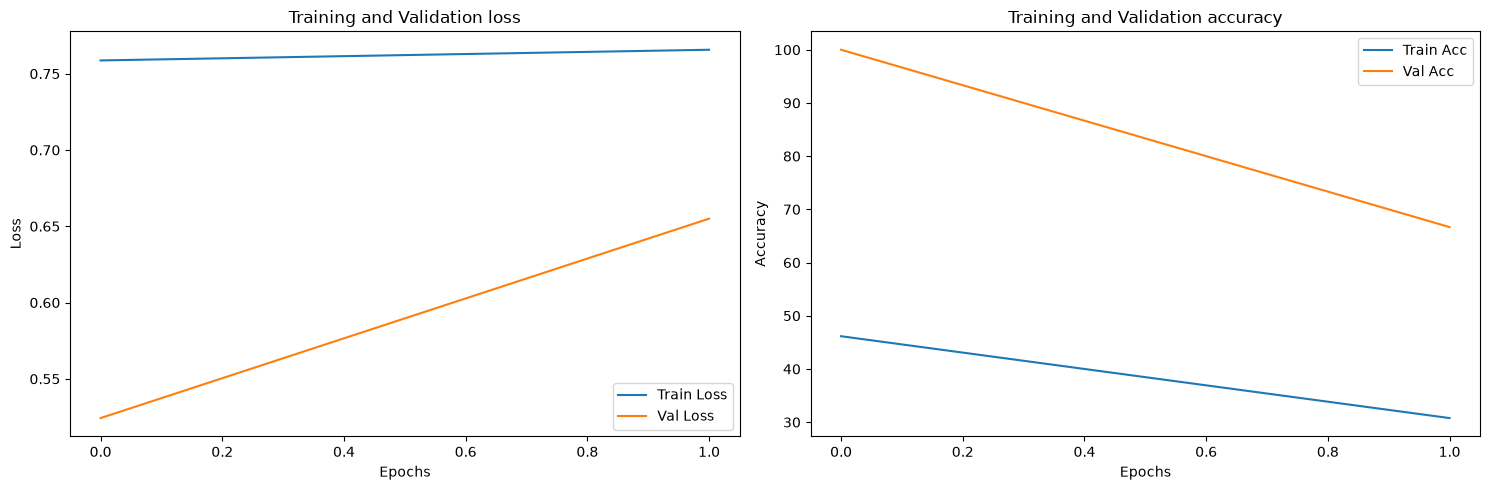

In [15]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(loss_train, label='Train Loss')
axs[0].plot(loss_val, label='Val Loss')
axs[0].set_title('Training and Validation loss')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(acc_train, label='Train Acc')
axs[1].plot(acc_val, label='Val Acc')
axs[1].set_title('Training and Validation accuracy')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.tight_layout()
plt.show()